## Preamble

In [5]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.002; nt=2000

ntr=100

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

# def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
#     tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

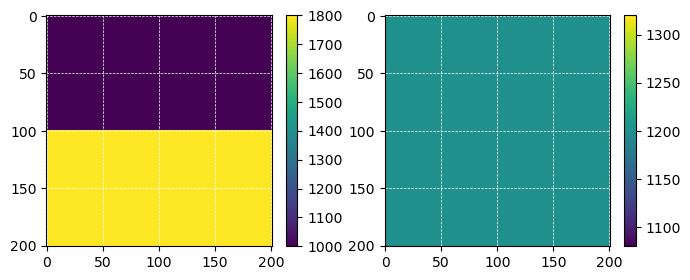

In [6]:
# True
!makevel nz=100 nx=$nx v000=1000 > c1
!makevel nz=101 nx=$nx v000=1800 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > true
!rm c1 c2 tmp

!makevel nz=1   nx=$nx v000=100  > topo

# Background
!makevel nz=$nz nx=$nx v000=1200 > init

#plot
plt.figure(figsize=(8,3))
true=read('true'); init=read('init')
plt.subplot(1,2,1); imshow(true)
plt.subplot(1,2,2); imshow(init)

In [14]:
%%writefile setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '10 10 1'
FILE_MODEL               true
MODEL_ATTRIBUTES         vs
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '40 500 500'
FR                      '40 10  0'
DR                      '0  20 0'
NR                      100

SCOMP                   vy
RCOMP                   vy #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           2000
DT           0.002
FPEAK        7

## for PFEI ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
WEIGHTING           'none'

PARAMETER           'vs:1000:1800'

SMOOTHING     'none'
#PRECO         'z^0'


#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'


#SNAPSHOT     vz
#NSNAPSHOT    50

IF_USE_CHECKPOINT   F

Overwriting setup_default


In [11]:
!make

#System
(cd ../../Modules/System; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modules/Signal; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Signal'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Signal'
#Modeling
(cd ../../Modules/Modeling; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Modeling'

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Modeling'
#Kernel
(cd ../../Modules/Kernel; make App=FWI)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Kernel'
m_empirical.f90 m_parametrizer_velocities-density.f90 m_querypoint.f90 m_weighter.f90

## SH

### vy-vy

#### Obs & Syn data

In [8]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_SH_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 653136 Jun 24 12:00 ../../exe/fwd_SH_FDSG_O4_
 Git Commit: 6c8a04a
 Git Branch: SH
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/24/2026
System time: 12:02:43
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D SH wave propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.494(

In [9]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_SH_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 653136 Jun 24 12:00 ../../exe/fwd_SH_FDSG_O4_
 Git Commit: 6c8a04a
 Git Branch: SH
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/24/2026
System time: 12:03:02
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D SH wave propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.494(

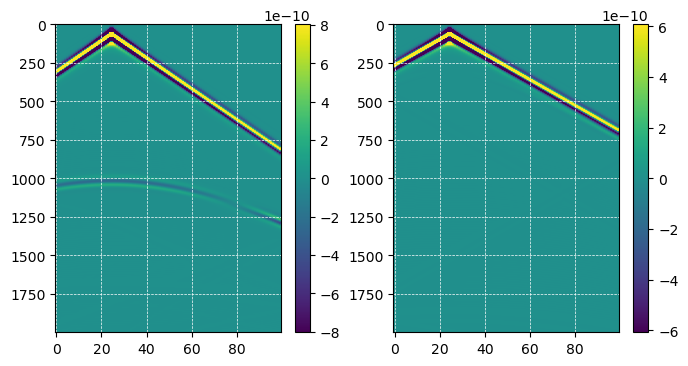

In [10]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [17]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS      1 " >> setup
run(app='../../exe/gradienttest_SH_FDSG_O4_velocities-density')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 978256 Jun 24 12:04 ../../exe/gradienttest_SH_FDSG_O4_velocities-density
 Git Commit: 6c8a04a
 Git Branch: SH
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/24/2026
System time: 12:06:24
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D SH wave propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev

 it----        2000
 fld_u minmax values:  -1.65780497E-12   1.10678415E-12
 Elapsed time to add stress source     2.92462111E-03
 Elapsed time to update stresses      0.242782235    
 Elapsed time to add source stresses   5.86688519E-04
 Elapsed time to update velocities    0.262386680    
 Elapsed time to extract field         9.07826424E-03
 Elapsed time to save boundary         8.15778971E-03
 Total elapsed time (min):   8.76527093E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_sfield%*  n1=249 perc=99
 xmovie < snap_sfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 DATA_FORMAT is NOT found, take default: su
 Found proper SU scalel = 1.00000000
 SU_SCALEL is NOT found, take default: 1.00000000
 Found proper SU scalco = 1.00000000
 SU_SCALCO is NOT found, take default: 1.00000000
 SU data write success.
 JOB is NOT found, take 0, '' or F
 IF_BLOOM : F
 UPDATE_WAVELET is NOT found, take 0, '' or F
 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI

 it----        1500
 fld_a minmax values:  -5.17138197E-20   5.37876197E-20
 fld_u minmax values:  -3.87049377E-12   3.64499273E-12
 it----        1000
 fld_a minmax values:  -5.91178705E-18   5.27818035E-18
 fld_u minmax values:  -8.14035617E-10   7.29086291E-10
 it----         500
 fld_a minmax values:  -5.93693929E-17   3.94218332E-17
 fld_u minmax values:  -1.22117549E-09   1.07677445E-09
 Elapsed time to load boundary            1.96630955E-02
 Elapsed time to update velocities       0.212284565    
 Elapsed time to rm source velocities     2.08425522E-03
 Elapsed time to update stresses         0.223885536    
 Elapsed time to rm source stresses       2.07209587E-03
 Total elapsed time for forward (min)   7.66649237E-03
  ---------------------------- 
 Elapsed time to add adjsource velocities    7.18832016E-03
 Elapsed time to update adj velocities      0.211976767    
 Elapsed time to add adjsource stresses      8.20875168E-03
 Elapsed time to update adj stresses        0.247708

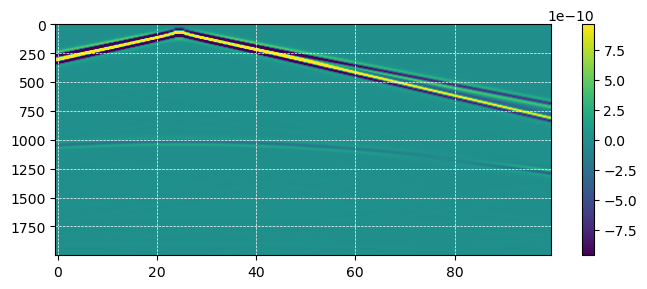

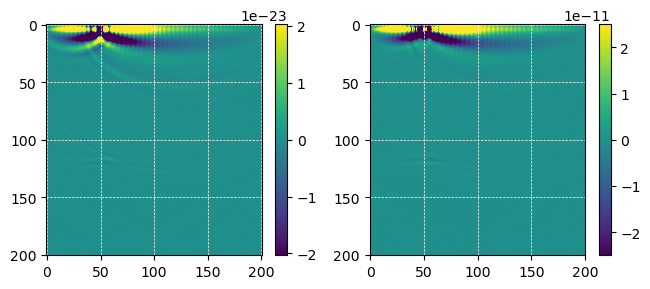

In [18]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(2*nx,nz))
grho=corr[:,:nx]
gimu=corr[:,nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(grho,perc=98)
plt.subplot(1,4,2); imshow(gimu,perc=98)

#### gradienttest_SH_FDSG_O4_velocities-density on gvs

In [19]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   35.0310898       35.0311012      -1.14440918      -1.19849670       1.04726243     T
 1st cond   9.99999975E-05   35.0310097       35.0311012     -0.915527344      -1.19849670       1.30907798     T
 1st cond   1.00000005E-03   35.0298576       35.0311012      -1.24359131      -1.19849670      0.963738382     T
 1st cond   9.99999978E-03   35.0189819       35.0311012      -1.21192932      -1.19849670      0.988916337     T
 1st cond  0.100000001       34.9107819       35.0311012      -1.20319366      -1.19849670      0.996096253     T
 1st cond   1.00000000       33.8945007       35.0311012      -1.13660049      -1.19849670       1.05445731     T


In [20]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   35.0311089       35.0311012     -0.762939453      -1.19849670       1.57089365     F
 1st cond  -9.99999975E-05   35.0311890       35.0311012     -0.877380371      -1.19849670       1.36599445     F
 1st cond  -1.00000005E-03   35.0321617       35.0311012      -1.06048584      -1.19849670       1.13013923     F
 1st cond  -9.99999978E-03   35.0430603       35.0311012      -1.19590759      -1.19849670       1.00216496     F
 1st cond -0.100000001       35.1513252       35.0311012      -1.20223999      -1.19849670      0.996886432     F
 1st cond  -1.00000000       36.2466660       35.0311012      -1.21556473      -1.19849670      0.985958755     F


#### gradienttest_SH_FDSG_O4_velocities-density on grho

In [22]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "PARAMETER   'rho:900:1100'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   1269.62854       1269.62891      -36.6210938      -17.3670139      0.474235266     T
 1st cond   9.99999975E-05   1269.62744       1269.62891      -14.6484375      -17.3670139       1.18558812     T
 1st cond   1.00000005E-03   1269.61218       1269.62891      -16.7236328      -17.3670139       1.03847134     T
 1st cond   9.99999978E-03   1269.46326       1269.62891      -16.5649414      -17.3670139       1.04841983     T
 1st cond  0.100000001       1268.00891       1269.62891      -16.1999512      -17.3670139       1.07204115     T
 1st cond   1.00000000       1254.16687       1269.62891      -15.4620361      -17.3670139       1.12320352     T


In [23]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "PARAMETER   'rho:900:1100'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   1269.62915       1269.62891      -24.4140625      -17.3670139      0.711352885     F
 1st cond  -9.99999975E-05   1269.62964       1269.62891      -7.32421875      -17.3670139       2.37117624     F
 1st cond  -1.00000005E-03   1269.64404       1269.62891      -15.1367178      -17.3670139       1.14734340     F
 1st cond  -9.99999978E-03   1269.78870       1269.62891      -15.9790039      -17.3670139       1.08686459     F
 1st cond -0.100000001       1271.25818       1269.62891      -16.2927246      -17.3670139       1.06593680     F
 1st cond  -1.00000000       1286.59595       1269.62891      -16.9670410      -17.3670139       1.02357352     F


## SH w/ FreeSurf [wait]

### vy-vy

#### Obs & Syn data

In [ ]:
!cp setup_default setup
!echo "IS_FREESURFACE          T" >> setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "ALPHAS      1 " >> setup
run(app='../../exe/gradienttest_PSV_FDSG_O4_velocities-density')

In [ ]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest_PSV_FDSG_O4_velocities-density on gvp

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

#### gradienttest_PSV_FDSG_O4_velocities-density on gvs

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

## SH on FreeSurf [wait]

### vz-vz

#### Obs & Syn data

In [ ]:
!cp setup_default setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
!echo "ALPHAS      1 " >> setup
run(app='../../exe/gradienttest_PSV_FDSG_O4_velocities-density')

In [ ]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest_PSV_FDSG_O4_velocities-density on gvp

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

#### gradienttest_PSV_FDSG_O4_velocities-density on gvs

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

In [ ]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "IS_FREESURFACE          T" >> setup
!echo "FS          '0 500 500'" >> setup
!echo "FR          '0 10  0'" >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out